# Bike Store SQL Practice and Visualization

This notebook uses the Bike Store dataset from Kaggle.  
The CSV files are loaded using pandas and then converted into SQL tables using SQLite.

## Notebook Structure
1. Setup and database creation  
2. Basic SQL queries  
3. JOIN queries  
4. Aggregate and GROUP BY queries  
5. Sales analysis  
6. Customer analysis  
7. Inventory analysis  
8. Visualizations  
9. Final insights

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import sqlite3 

# Base path of Kaggle dataset
base_path = '/kaggle/input/datasets/dillonmyrick/bike-store-sample-database'

# Load all CSV files
brands = pd.read_csv(f'{base_path}/brands.csv')
categories = pd.read_csv(f'{base_path}/categories.csv')
customers = pd.read_csv(f'{base_path}/customers.csv')
orders = pd.read_csv(f'{base_path}/orders.csv')
order_items = pd.read_csv(f'{base_path}/order_items.csv')
products = pd.read_csv(f'{base_path}/products.csv')
stocks = pd.read_csv(f'{base_path}/stocks.csv')
stores = pd.read_csv(f'{base_path}/stores.csv')
staffs = pd.read_csv(f'{base_path}/staffs.csv')

# Create SQLite in-memory database
conn = sqlite3.connect(':memory:')

# Convert DataFrames to SQL tables
brands.to_sql('brands', conn, index=False, if_exists='replace')
categories.to_sql('categories', conn, index=False, if_exists='replace')
customers.to_sql('customers', conn, index=False, if_exists='replace')
orders.to_sql('orders', conn, index=False, if_exists='replace')
order_items.to_sql('order_items', conn, index=False, if_exists='replace')
products.to_sql('products', conn, index=False, if_exists='replace')
stocks.to_sql('stocks', conn, index=False, if_exists='replace')
stores.to_sql('stores', conn, index=False, if_exists='replace')
staffs.to_sql('staffs', conn, index=False, if_exists='replace')

print("All files loaded successfully into SQLite database.")

# Check table names
query = """
SELECT name
FROM sqlite_master
WHERE type='table'
ORDER BY name;
"""
display(pd.read_sql_query(query, conn))

All files loaded successfully into SQLite database.


,name
0,brands
1,categories
2,customers
3,order_items
4,orders
5,products
6,staffs
7,stocks
8,stores


## 2. Basic SQL Queries
This section covers simple SQL practice such as selecting columns, filtering rows, sorting results, and limiting output.

In [2]:
# 1. Show customer data
query_customers = """
SELECT *
FROM customers
LIMIT 10;
"""
df_customers = pd.read_sql_query(query_customers, conn)

# 2. Show product details
query_products = """
SELECT product_id, product_name, model_year, list_price
FROM products
ORDER BY list_price DESC
LIMIT 15;
"""
df_products = pd.read_sql_query(query_products, conn)

# 3. Expensive products
query_expensive = """
SELECT product_name, list_price
FROM products
WHERE list_price > 3000
ORDER BY list_price DESC;
"""
df_expensive = pd.read_sql_query(query_expensive, conn)

# 4. Orders in descending date order
query_orders = """
SELECT order_id, customer_id, order_date, order_status
FROM orders
ORDER BY order_date DESC
LIMIT 15;
"""
df_orders = pd.read_sql_query(query_orders, conn)

print("Customers preview:")
display(df_customers)

print("Products preview:")
display(df_products)

print("Expensive products:")
display(df_expensive)

print("Recent orders:")
display(df_orders)

Customers preview:


,customer_id,first_name,last_name,phone,email,street,city,state,zip_code
0,1,Debra,Burks,None,debra.burks@yahoo.com,9273 Thorne Ave.,Orchard Park,NY,14127
1,2,Kasha,Todd,None,kasha.todd@yahoo.com,910 Vine Street,Campbell,CA,95008
2,3,Tameka,Fisher,None,tameka.fisher@aol.com,769C Honey Creek St.,Redondo Beach,CA,90278
3,4,Daryl,Spence,None,daryl.spence@aol.com,988 Pearl Lane,Uniondale,NY,11553
4,5,Charolette,Rice,(916) 381-6003,charolette.rice@msn.com,107 River Dr.,Sacramento,CA,95820
5,6,Lyndsey,Bean,None,lyndsey.bean@hotmail.com,769 West Road,Fairport,NY,14450
6,7,Latasha,Hays,(716) 986-3359,latasha.hays@hotmail.com,7014 Manor Station Rd.,Buffalo,NY,14215
7,8,Jacquline,Duncan,None,jacquline.duncan@yahoo.com,15 Brown St.,Jackson Heights,NY,11372
8,9,Genoveva,Baldwin,None,genoveva.baldwin@msn.com,8550 Spruce Drive,Port Washington,NY,11050
9,10,Pamelia,Newman,None,pamelia.newman@gmail.com,476 Chestnut Ave.,Monroe,NY,10950


Products preview:


,product_id,product_name,model_year,list_price
0,155,Trek Domane SLR 9 Disc - 2018,2018,11999.99
1,149,Trek Domane SLR 8 Disc - 2018,2018,7499.99
2,51,Trek Silque SLR 8 Women's - 2017,2017,6499.99
3,156,Trek Domane SL Frameset - 2018,2018,6499.99
4,157,Trek Domane SL Frameset Women's - 2018,2018,6499.99
5,169,Trek Emonda SLR 8 - 2018,2018,6499.99
6,50,Trek Silque SLR 7 Women's - 2017,2017,5999.99
7,56,Trek Domane SLR 6 Disc - 2017,2017,5499.99
8,148,Trek Domane SL 8 Disc - 2018,2018,5499.99
9,154,Trek Domane SLR 6 Disc Women's - 2018,2018,5499.99


Expensive products:


,product_name,list_price
0,Trek Domane SLR 9 Disc - 2018,11999.99
1,Trek Domane SLR 8 Disc - 2018,7499.99
2,Trek Silque SLR 8 Women's - 2017,6499.99
3,Trek Domane SL Frameset - 2018,6499.99
4,Trek Domane SL Frameset Women's - 2018,6499.99
5,Trek Emonda SLR 8 - 2018,6499.99
6,Trek Silque SLR 7 Women's - 2017,5999.99
7,Trek Domane SLR 6 Disc - 2017,5499.99
8,Trek Domane SL 8 Disc - 2018,5499.99
9,Trek Domane SLR 6 Disc Women's - 2018,5499.99


Recent orders:


,order_id,customer_id,order_date,order_status
0,1615,136,2018-12-28,3
1,1614,135,2018-11-28,3
2,1613,1,2018-11-18,3
3,1612,3,2018-10-21,3
4,1611,6,2018-09-06,3
5,1610,15,2018-08-25,3
6,1609,10,2018-08-23,3
7,1608,53,2018-07-12,3
8,1607,33,2018-07-11,3
9,1606,119,2018-07-10,3


## 3. JOIN Queries
This section combines multiple tables to extract relational insights from the dataset.

In [3]:
# 1. Product details with brand and category
query_product_details = """
SELECT 
    p.product_id,
    p.product_name,
    b.brand_name,
    c.category_name,
    p.model_year,
    p.list_price
FROM products p
JOIN brands b
    ON p.brand_id = b.brand_id
JOIN categories c
    ON p.category_id = c.category_id
LIMIT 20;
"""
df_product_details = pd.read_sql_query(query_product_details, conn)

# 2. Orders with customer and store details
query_order_details = """
SELECT 
    o.order_id,
    o.order_date,
    c.first_name || ' ' || c.last_name AS customer_name,
    s.store_name,
    o.order_status
FROM orders o
JOIN customers c
    ON o.customer_id = c.customer_id
JOIN stores s
    ON o.store_id = s.store_id
LIMIT 20;
"""
df_order_details = pd.read_sql_query(query_order_details, conn)

# 3. Stock with product and store details
query_stock_details = """
SELECT 
    s.store_name,
    p.product_name,
    st.quantity
FROM stocks st
JOIN stores s
    ON st.store_id = s.store_id
JOIN products p
    ON st.product_id = p.product_id
ORDER BY st.quantity DESC
LIMIT 20;
"""
df_stock_details = pd.read_sql_query(query_stock_details, conn)

print("Product details with brand and category:")
display(df_product_details)

print("Orders with customer and store:")
display(df_order_details)

print("Stock details:")
display(df_stock_details)

Product details with brand and category:


,product_id,product_name,brand_name,category_name,model_year,list_price
0,1,Trek 820 - 2016,Trek,Mountain Bikes,2016,379.99
1,2,Ritchey Timberwolf Frameset - 2016,Ritchey,Mountain Bikes,2016,749.99
2,3,Surly Wednesday Frameset - 2016,Surly,Mountain Bikes,2016,999.99
3,4,Trek Fuel EX 8 29 - 2016,Trek,Mountain Bikes,2016,2899.99
4,5,Heller Shagamaw Frame - 2016,Heller,Mountain Bikes,2016,1320.99
5,6,Surly Ice Cream Truck Frameset - 2016,Surly,Mountain Bikes,2016,469.99
6,7,Trek Slash 8 27.5 - 2016,Trek,Mountain Bikes,2016,3999.99
7,8,Trek Remedy 29 Carbon Frameset - 2016,Trek,Mountain Bikes,2016,1799.99
8,9,Trek Conduit+ - 2016,Trek,Electric Bikes,2016,2999.99
9,10,Surly Straggler - 2016,Surly,Cyclocross Bicycles,2016,1549.00


Orders with customer and store:


,order_id,order_date,customer_name,store_name,order_status
0,1,2016-01-01,Johnathan Velazquez,Santa Cruz Bikes,4
1,2,2016-01-01,Jaqueline Cummings,Baldwin Bikes,4
2,3,2016-01-02,Joshua Robertson,Baldwin Bikes,4
3,4,2016-01-03,Nova Hess,Santa Cruz Bikes,4
4,5,2016-01-03,Arla Ellis,Baldwin Bikes,4
5,6,2016-01-04,Sharyn Hopkins,Baldwin Bikes,4
6,7,2016-01-04,Laureen Paul,Baldwin Bikes,4
7,8,2016-01-04,Leslie Higgins,Baldwin Bikes,4
8,9,2016-01-05,Neil Mccall,Santa Cruz Bikes,4
9,10,2016-01-05,Alane Munoz,Baldwin Bikes,4


Stock details:


,store_name,product_name,quantity
0,Santa Cruz Bikes,Surly Ice Cream Truck Frameset - 2017,30
1,Santa Cruz Bikes,Trek Powerfly 8 FS Plus - 2017,30
2,Santa Cruz Bikes,Electra Townie Original 7D - 2017,30
3,Santa Cruz Bikes,Sun Bicycles Cruz 3 - 2017,30
4,Santa Cruz Bikes,Sun Bicycles Cruz 3 - 2017,30
5,Santa Cruz Bikes,Sun Bicycles Cruz 7 - Women's - 2017,30
6,Santa Cruz Bikes,Trek XM700+ Lowstep - 2018,30
7,Santa Cruz Bikes,Trek Lift+ - 2018,30
8,Santa Cruz Bikes,Electra Moto 3i - 2018,30
9,Santa Cruz Bikes,Electra Sweet Ride 3i (20-inch) - Girls' - 2018,30


## 4. Aggregate and GROUP BY Queries
This section uses COUNT, SUM, AVG, and GROUP BY to summarize the data.

In [4]:
# 1. Customers by state
query_customers_state = """
SELECT state, COUNT(*) AS total_customers
FROM customers
GROUP BY state
ORDER BY total_customers DESC;
"""
df_customers_state = pd.read_sql_query(query_customers_state, conn)

# 2. Products by category
query_category_products = """
SELECT 
    c.category_name,
    COUNT(*) AS total_products
FROM products p
JOIN categories c
    ON p.category_id = c.category_id
GROUP BY c.category_name
ORDER BY total_products DESC;
"""
df_category_products = pd.read_sql_query(query_category_products, conn)

# 3. Products by brand
query_brand_products = """
SELECT 
    b.brand_name,
    COUNT(*) AS total_products
FROM products p
JOIN brands b
    ON p.brand_id = b.brand_id
GROUP BY b.brand_name
ORDER BY total_products DESC;
"""
df_brand_products = pd.read_sql_query(query_brand_products, conn)

# 4. Total stock by store
query_store_stock = """
SELECT 
    s.store_name,
    SUM(st.quantity) AS total_stock
FROM stocks st
JOIN stores s
    ON st.store_id = s.store_id
GROUP BY s.store_name
ORDER BY total_stock DESC;
"""
df_store_stock = pd.read_sql_query(query_store_stock, conn)

print("Customers by state:")
display(df_customers_state)

print("Products by category:")
display(df_category_products)

print("Products by brand:")
display(df_brand_products)

print("Total stock by store:")
display(df_store_stock)

Customers by state:


,state,total_customers
0,NY,1019
1,CA,284
2,TX,142


Products by category:


,category_name,total_products
0,Cruisers Bicycles,78
1,Road Bikes,60
2,Mountain Bikes,60
3,Children Bicycles,59
4,Comfort Bicycles,30
5,Electric Bikes,24
6,Cyclocross Bicycles,10


Products by brand:


,brand_name,total_products
0,Trek,135
1,Electra,118
2,Surly,25
3,Sun Bicycles,23
4,Haro,10
5,Strider,3
6,Pure Cycles,3
7,Heller,3
8,Ritchey,1


Total stock by store:


,store_name,total_stock
0,Rowlett Bikes,4620
1,Santa Cruz Bikes,4532
2,Baldwin Bikes,4359


## 5. Sales Analysis
This section focuses on revenue-based business analysis using order_items, orders, products, brands, and categories.

In [5]:
# Revenue formula = quantity * list_price * (1 - discount)

# 1. Revenue by order
query_order_revenue = """
SELECT 
    order_id,
    ROUND(SUM(quantity * list_price * (1 - discount)), 2) AS order_total
FROM order_items
GROUP BY order_id
ORDER BY order_total DESC
LIMIT 20;
"""
df_order_revenue = pd.read_sql_query(query_order_revenue, conn)

# 2. Revenue by store
query_store_revenue = """
SELECT 
    s.store_name,
    ROUND(SUM(oi.quantity * oi.list_price * (1 - oi.discount)), 2) AS total_revenue
FROM orders o
JOIN order_items oi
    ON o.order_id = oi.order_id
JOIN stores s
    ON o.store_id = s.store_id
GROUP BY s.store_name
ORDER BY total_revenue DESC;
"""
df_store_revenue = pd.read_sql_query(query_store_revenue, conn)

# 3. Revenue by category
query_category_revenue = """
SELECT 
    c.category_name,
    ROUND(SUM(oi.quantity * oi.list_price * (1 - oi.discount)), 2) AS total_revenue
FROM order_items oi
JOIN products p
    ON oi.product_id = p.product_id
JOIN categories c
    ON p.category_id = c.category_id
GROUP BY c.category_name
ORDER BY total_revenue DESC;
"""
df_category_revenue = pd.read_sql_query(query_category_revenue, conn)

# 4. Revenue by brand
query_brand_revenue = """
SELECT 
    b.brand_name,
    ROUND(SUM(oi.quantity * oi.list_price * (1 - oi.discount)), 2) AS total_revenue
FROM order_items oi
JOIN products p
    ON oi.product_id = p.product_id
JOIN brands b
    ON p.brand_id = b.brand_id
GROUP BY b.brand_name
ORDER BY total_revenue DESC;
"""
df_brand_revenue = pd.read_sql_query(query_brand_revenue, conn)

# 5. Monthly revenue trend
query_monthly_revenue = """
SELECT 
    strftime('%Y-%m', o.order_date) AS month,
    ROUND(SUM(oi.quantity * oi.list_price * (1 - oi.discount)), 2) AS monthly_revenue
FROM orders o
JOIN order_items oi
    ON o.order_id = oi.order_id
GROUP BY strftime('%Y-%m', o.order_date)
ORDER BY month;
"""
df_monthly_revenue = pd.read_sql_query(query_monthly_revenue, conn)

print("Revenue by order:")
display(df_order_revenue)

print("Revenue by store:")
display(df_store_revenue)

print("Revenue by category:")
display(df_category_revenue)

print("Revenue by brand:")
display(df_brand_revenue)

print("Monthly revenue trend:")
display(df_monthly_revenue)

Revenue by order:


,order_id,order_total
0,1541,29147.03
1,937,27050.72
2,1506,25574.96
3,1482,25365.43
4,1364,24890.62
5,930,24607.03
6,1348,20648.95
7,1334,20509.43
8,973,20177.75
9,1118,19329.95


Revenue by store:


,store_name,total_revenue
0,Baldwin Bikes,5215751.28
1,Santa Cruz Bikes,1605823.04
2,Rowlett Bikes,867542.24


Revenue by category:


,category_name,total_revenue
0,Mountain Bikes,2715079.53
1,Road Bikes,1665098.49
2,Cruisers Bicycles,995032.62
3,Electric Bikes,916684.78
4,Cyclocross Bicycles,711011.84
5,Comfort Bicycles,394020.10
6,Children Bicycles,292189.20


Revenue by brand:


,brand_name,total_revenue
0,Trek,4602754.35
1,Electra,1205320.82
2,Surly,949507.06
3,Sun Bicycles,341994.93
4,Haro,185384.55
5,Heller,171459.08
6,Pure Cycles,149476.34
7,Ritchey,78898.95
8,Strider,4320.48


Monthly revenue trend:


,month,monthly_revenue
0,2016-01,215146.42
1,2016-02,156112.32
2,2016-03,180600.33
3,2016-04,167144.05
4,2016-05,205270.01
5,2016-06,210562.12
6,2016-07,199556.81
7,2016-08,225657.38
8,2016-09,273091.61
9,2016-10,212078.08


## 6. Customer Analysis
This section identifies valuable customers and their contribution to sales.

In [6]:
# Top customers by spending
query_top_customers = """
SELECT 
    c.customer_id,
    c.first_name || ' ' || c.last_name AS customer_name,
    ROUND(SUM(oi.quantity * oi.list_price * (1 - oi.discount)), 2) AS total_spent
FROM customers c
JOIN orders o
    ON c.customer_id = o.customer_id
JOIN order_items oi
    ON o.order_id = oi.order_id
GROUP BY c.customer_id, customer_name
ORDER BY total_spent DESC
LIMIT 10;
"""
df_top_customers = pd.read_sql_query(query_top_customers, conn)

display(df_top_customers)

,customer_id,customer_name,total_spent
0,94,Sharyn Hopkins,34807.94
1,10,Pamelia Newman,33634.26
2,75,Abby Gamble,32803.01
3,6,Lyndsey Bean,32675.07
4,16,Emmitt Sanchez,31925.89
5,73,Melanie Hayes,31913.69
6,1,Debra Burks,27888.18
7,61,Elinore Aguilar,25636.45
8,93,Corrina Sawyer,25612.70
9,122,Shena Carter,24890.62


## 7. Inventory Analysis
This section examines stock levels, low-stock products, and product availability across stores.

In [7]:
# 1. Total stock by category
query_stock_category = """
SELECT 
    c.category_name,
    SUM(st.quantity) AS total_stock
FROM stocks st
JOIN products p
    ON st.product_id = p.product_id
JOIN categories c
    ON p.category_id = c.category_id
GROUP BY c.category_name
ORDER BY total_stock DESC;
"""
df_stock_category = pd.read_sql_query(query_stock_category, conn)

# 2. Lowest stock products
query_low_stock = """
SELECT 
    s.store_name,
    p.product_name,
    st.quantity
FROM stocks st
JOIN stores s
    ON st.store_id = s.store_id
JOIN products p
    ON st.product_id = p.product_id
ORDER BY st.quantity ASC
LIMIT 20;
"""
df_low_stock = pd.read_sql_query(query_low_stock, conn)

display(df_stock_category)
display(df_low_stock)

,category_name,total_stock
0,Cruisers Bicycles,3378
1,Mountain Bikes,2654
2,Children Bicycles,2608
3,Road Bikes,2091
4,Comfort Bicycles,1258
5,Electric Bikes,1108
6,Cyclocross Bicycles,414


,store_name,product_name,quantity
0,Santa Cruz Bikes,Surly Ice Cream Truck Frameset - 2016,0
1,Santa Cruz Bikes,Trek Remedy 29 Carbon Frameset - 2016,0
2,Santa Cruz Bikes,Trek Farley Alloy Frameset - 2017,0
3,Santa Cruz Bikes,Trek Fuel EX 5 27.5 Plus - 2017,0
4,Santa Cruz Bikes,Haro Shredder 20 - 2017,0
5,Santa Cruz Bikes,Trek Emonda SLR 6 - 2018,0
6,Santa Cruz Bikes,Surly Pack Rat - 2018,0
7,Santa Cruz Bikes,Surly Straggler - 2018,0
8,Santa Cruz Bikes,Electra Townie Original 3i EQ Ladies' - 2018,0
9,Santa Cruz Bikes,Electra Townie Original 1 - 2018,0


## 8. Visualizations
This section transforms SQL output tables into charts for easier interpretation.

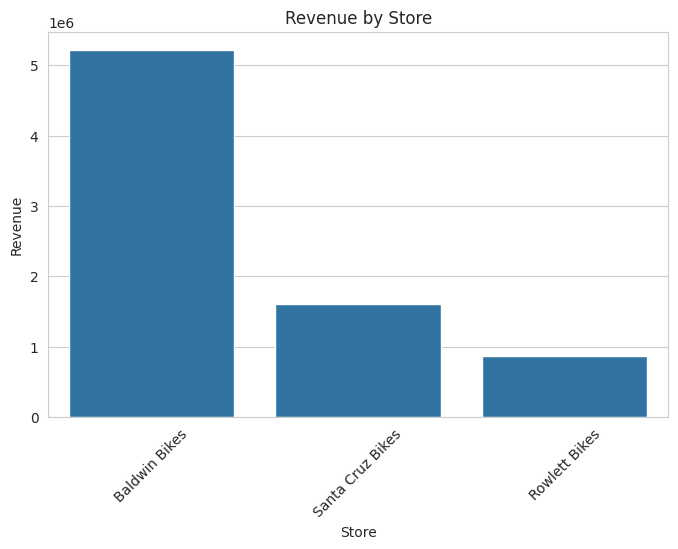

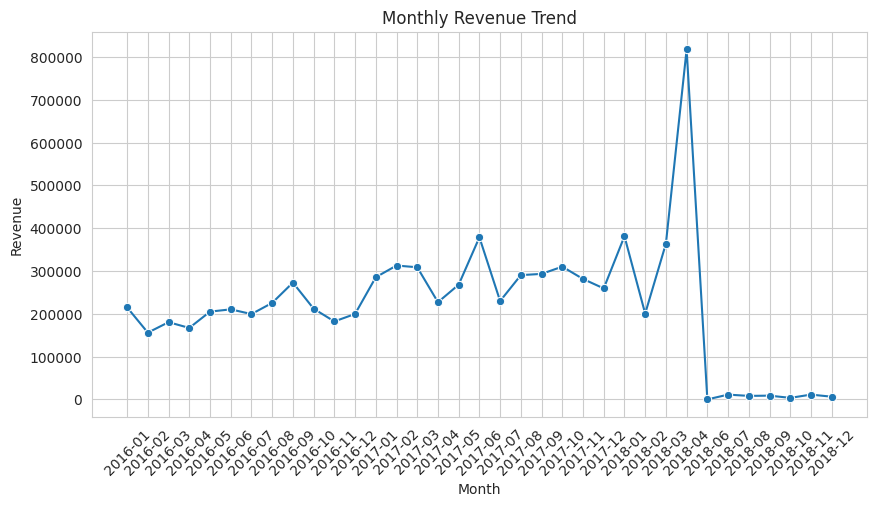

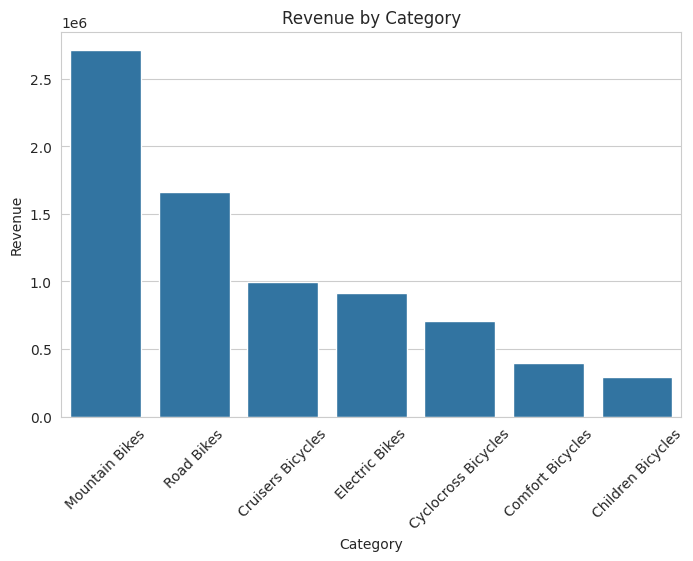

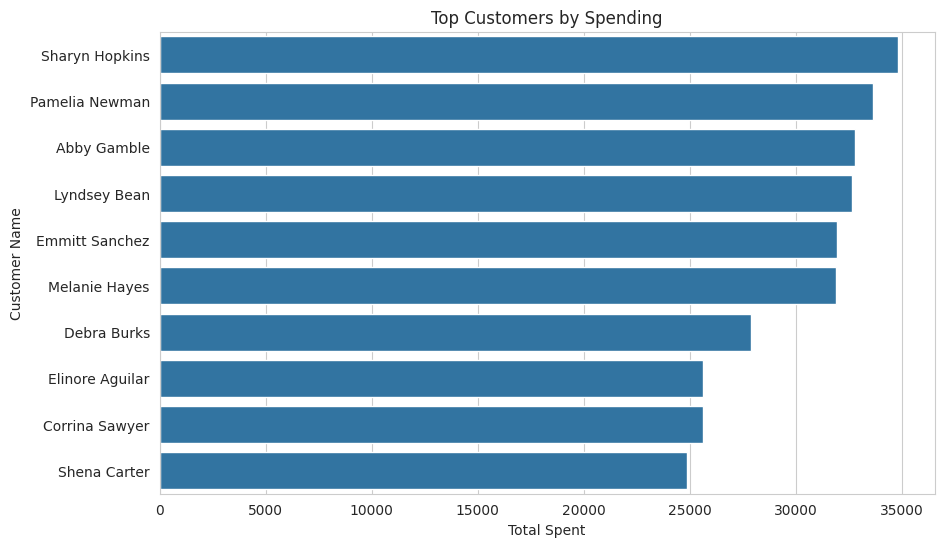

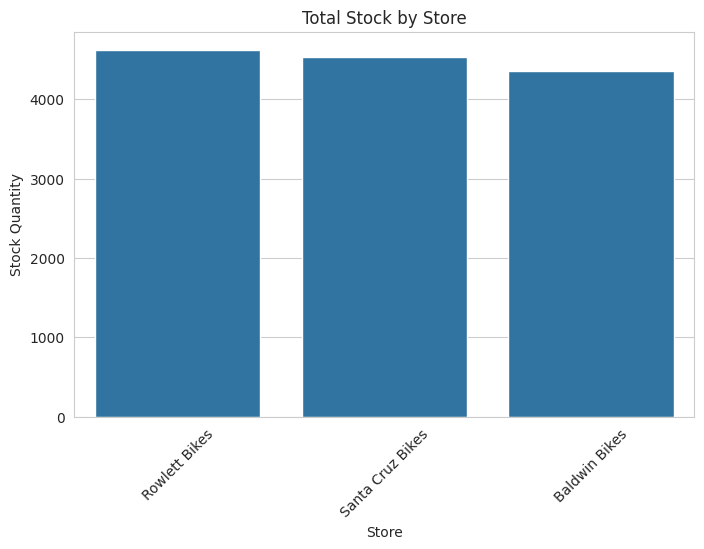

In [8]:
sns.set_style("whitegrid")

# Revenue by store
plt.figure(figsize=(8,5))
sns.barplot(data=df_store_revenue, x='store_name', y='total_revenue')
plt.title('Revenue by Store')
plt.xlabel('Store')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

# Monthly revenue trend
plt.figure(figsize=(10,5))
sns.lineplot(data=df_monthly_revenue, x='month', y='monthly_revenue', marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

# Revenue by category
plt.figure(figsize=(8,5))
sns.barplot(data=df_category_revenue, x='category_name', y='total_revenue')
plt.title('Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Revenue')
plt.xticks(rotation=45)
plt.show()

# Top customers by spending
plt.figure(figsize=(10,6))
sns.barplot(data=df_top_customers, y='customer_name', x='total_spent')
plt.title('Top Customers by Spending')
plt.xlabel('Total Spent')
plt.ylabel('Customer Name')
plt.show()

# Stock by store
plt.figure(figsize=(8,5))
sns.barplot(data=df_store_stock, x='store_name', y='total_stock')
plt.title('Total Stock by Store')
plt.xlabel('Store')
plt.ylabel('Stock Quantity')
plt.xticks(rotation=45)
plt.show()

## 9. Final Insights
This final section summarizes key findings from the analysis.

In [9]:
print("Store with highest revenue:")
print(df_store_revenue.iloc[0])

print("\nCategory with highest revenue:")
print(df_category_revenue.iloc[0])

print("\nBrand with highest revenue:")
print(df_brand_revenue.iloc[0])

print("\nTop customer by spending:")
print(df_top_customers.iloc[0])

print("\nStore with highest stock:")
print(df_store_stock.iloc[0])

Store with highest revenue:
store_name       Baldwin Bikes
total_revenue       5215751.28
Name: 0, dtype: object

Category with highest revenue:
category_name    Mountain Bikes
total_revenue        2715079.53
Name: 0, dtype: object

Brand with highest revenue:
brand_name             Trek
total_revenue    4602754.35
Name: 0, dtype: object

Top customer by spending:
customer_id                  94
customer_name    Sharyn Hopkins
total_spent            34807.94
Name: 0, dtype: object

Store with highest stock:
store_name     Rowlett Bikes
total_stock             4620
Name: 0, dtype: object


In [10]:
#close connection
conn.close()
print("SQLite connection closed successfully.")

SQLite connection closed successfully.


## Final Notes

This notebook demonstrates SQL-based data analysis using the Bike Store dataset.  
It covers relational data handling, joins, aggregations, and business insights through SQL queries and visualizations.

---

### **Author**

**Mukul Girdhar**  
Aspiring Data Analyst  

---

### **Tools & Technologies Used**
- Python (pandas)
- SQLite (SQL queries)
- Matplotlib & Seaborn (visualization)
- Jupyter Notebook

---

### **Key Learnings**
- Working with relational datasets using SQL
- Performing joins and aggregations
- Deriving business insights from sales and customer data
- Visualizing SQL outputs for better interpretation